Data Cleaning and Visualization Using Python - 3.6 Project - 02/15/2026 - edwgol5635


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', context='notebook')

excel_path = r'C:\\Files\\Excel\\Project\\Happiness_Development_Index.xlsx'
xls = pd.ExcelFile(excel_path, engine='openpyxl')
sheet_name = 'HDI' if 'HDI' in xls.sheet_names else xls.sheet_names[-1]
df = pd.read_excel(xls, sheet_name=sheet_name, engine='openpyxl')

cols = {
    'HDI Rank': 'rank',
    'Country': 'country',
    'Human Development Index (HDI) ': 'hdi',
    'Human Development Index (HDI)': 'hdi',
    'Life expectancy at birth': 'life_exp',
    'Expected years of schooling': 'exp_school',
    'Mean years of schooling': 'mean_school',
    'Gross national income (GNI) per capita': 'gni_pc'
}
df = df.rename(columns=cols)

for c in ['rank','hdi','life_exp','exp_school','mean_school','gni_pc']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

keep = [c for c in ['rank','country','hdi','life_exp','exp_school','mean_school','gni_pc'] if c in df.columns]
df = df[keep].dropna(subset=['hdi']).copy()

print('Rows:', len(df))
df.head()


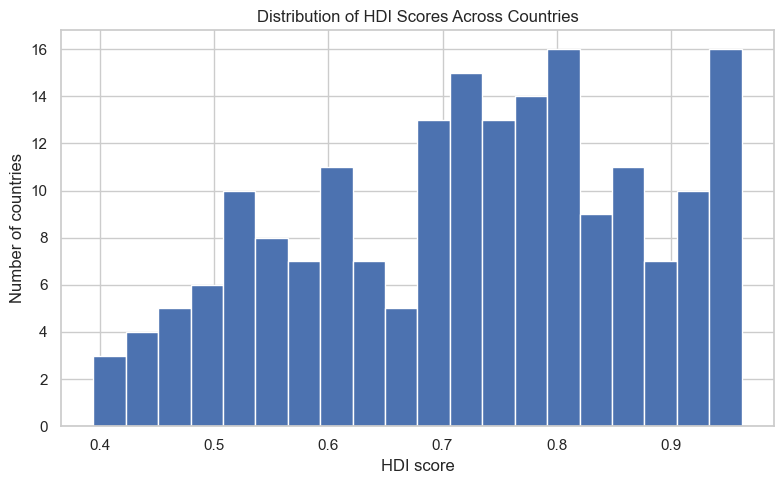

In [2]:

plt.figure(figsize=(8,5))
plt.hist(df['hdi'].dropna(), bins=20, color='#4C72B0', edgecolor='white')
plt.title('Distribution of HDI Scores Across Countries')
plt.xlabel('HDI score')
plt.ylabel('Number of countries')
plt.tight_layout()
plt.show()


C:\Users\Student\AppData\Local\Temp\ipykernel_1472\436230227.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=_top10, x='hdi', y='country', palette='viridis')


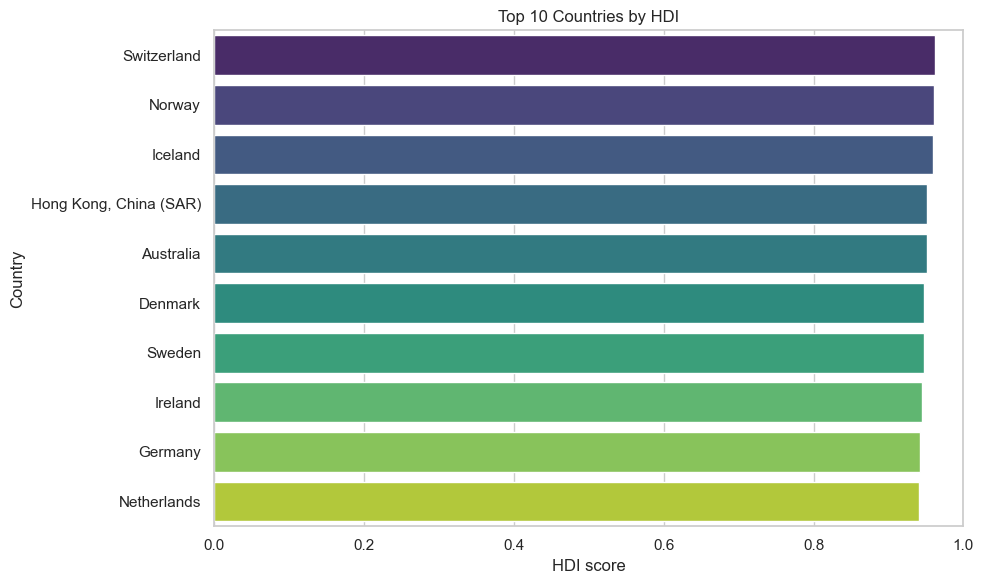

In [3]:

_top10 = df.sort_values(['hdi','rank'], ascending=[False, True]).head(10)
plt.figure(figsize=(10,6))
import seaborn as sns
sns.barplot(data=_top10, x='hdi', y='country', palette='viridis')
plt.title('Top 10 Countries by HDI')
plt.xlabel('HDI score')
plt.ylabel('Country')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


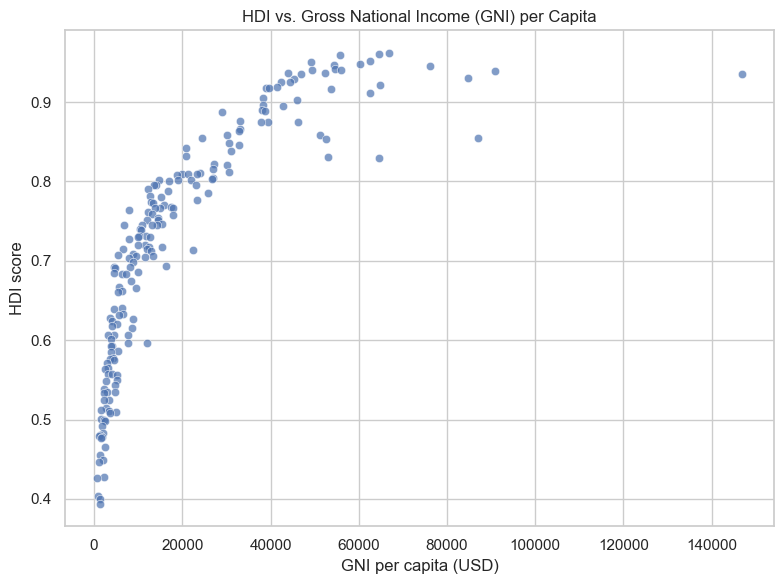

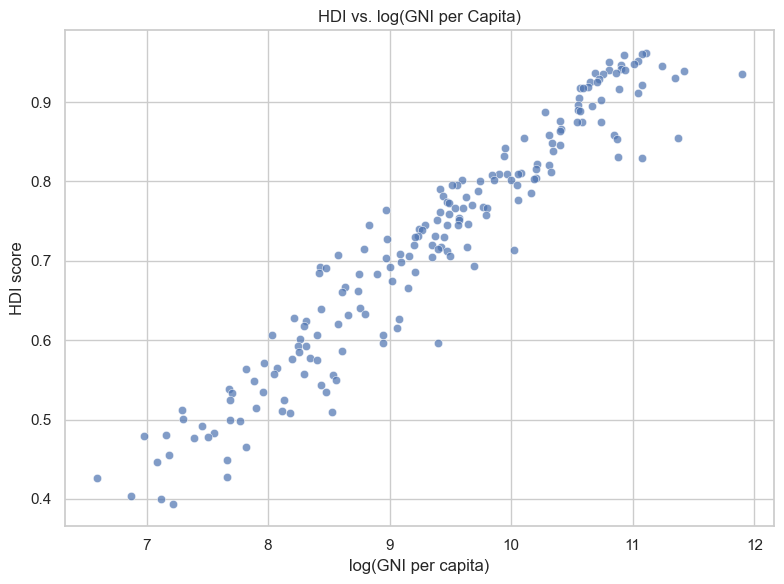

In [4]:

plt.figure(figsize=(8,6))
import seaborn as sns
sns.scatterplot(data=df, x='gni_pc', y='hdi', alpha=0.7)
plt.title('HDI vs. Gross National Income (GNI) per Capita')
plt.xlabel('GNI per capita (USD)')
plt.ylabel('HDI score')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=df[df['gni_pc']>0], x=np.log(df.loc[df['gni_pc']>0, 'gni_pc']), y='hdi', alpha=0.7)
plt.title('HDI vs. log(GNI per Capita)')
plt.xlabel('log(GNI per capita)')
plt.ylabel('HDI score')
plt.tight_layout()
plt.show()


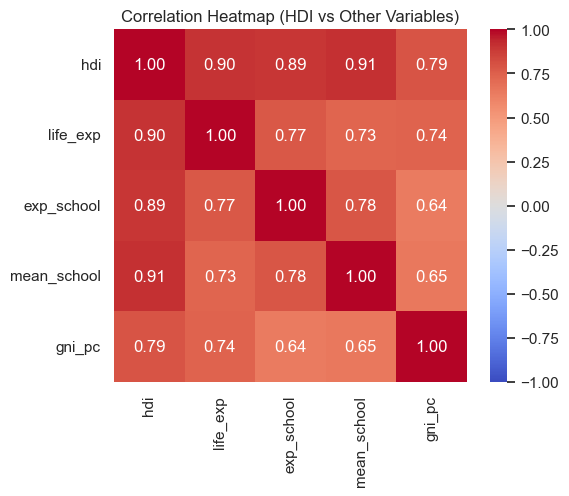

In [5]:

num_cols = ['hdi','life_exp','exp_school','mean_school','gni_pc']
_corr = df[num_cols].corr()
plt.figure(figsize=(6,5))
import seaborn as sns
sns.heatmap(_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', square=True)
plt.title('Correlation Heatmap (HDI vs Other Variables)')
plt.tight_layout()
plt.show()
